# Mod6L5 Data Challenge — Interpreting SLR Output (Dec 2023 NYC Taxi)


**Format:** We Do (Instructor prompts) → You Do (Student work) → We Share (reflection)


**Goal:** Choose **one** dependent variable (**Y**) from the taxi dataset and build **three** simple linear regressions (each with a different single **X**) on **Dec 2023** rides. For each model, interpret the **coefficient**, **intercept**, **p‑value**, and **R‑squared** in plain business language. Then decide which model is “better” *for decision‑making* and why.


> **Reminder:** No train/test split or advanced metrics today. We focus on reading `.summary()` and communicating results.

## Instructor Section (10 mins)

**Follow these steps/considerations as you work**


1) **Pick a useful Y.** Which outcome would someone actually act on?  Who is the stakeholder for your Y?

*Avoid constructing Y that bakes in your X (e.g., avoid using `fare_amount` as X when Y = `total_amount` which already includes fare).*


2) **Choose three X’s** you can know at decision time, and that plausibly relate to Y. 

*You may engineer a feature to use in the model if you like*

*Note:  SLR needs numeric only inputs so variables like `PULocationID` can't be used (categorical → not for SLR today unless you transform; stick to numeric X for this exercise)*


3) **Interpretation lenses:**
- **Units:** Always state slope in units (e.g., “per mile”, “per minute”).
- **p‑value:** Does evidence suggest the slope ≠ 0?
- **R²:** How much of Y’s variation is captured by this X? Does that help the decision?
- **Intercept:** Is X=0 meaningful? If not, say it’s a math anchor.
- **Plausibility:** Does the direction/size make sense (e.g., longer trip → higher fare)?


4) **Better ≠ only higher R².** Weigh **interpretability**, **actionability**, and **evidence** (p‑value, CI) alongside R².

## YOU DO (40 mins)

In [53]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt


### Step 1: Read in the Data & Choose your **Y** (dependent variable)

Pick one from the 2023_Yellow_Taxi_Trip_Data_20251015 csv file  

In [57]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv',low_memory=False)
df.dtypes

# converting to numeric
num_cols = ['fare_amount', 'tip_amount', 'trip_distance','total_amount']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
    )
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0) & (df['total_amount'] > 0)]

# Removing outliers using IQR method for fare_amount and total_amount
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers_iqr(df, 'fare_amount')
df = remove_outliers_iqr(df, 'total_amount')

# My Y variable is dollar/mile : fare efficiency, fare_amount / trip_distance
df['dollar_per_mile'] = df['fare_amount'] / df['trip_distance']
df = df.dropna(subset=['dollar_per_mile'])

df['other_fees'] = df['total_amount'] - df['fare_amount']

array([[<Axes: title={'center': 'VendorID'}>,
        <Axes: title={'center': 'passenger_count'}>,
        <Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>],
       [<Axes: title={'center': 'PULocationID'}>,
        <Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'fare_amount'}>],
       [<Axes: title={'center': 'extra'}>,
        <Axes: title={'center': 'mta_tax'}>,
        <Axes: title={'center': 'tip_amount'}>,
        <Axes: title={'center': 'tolls_amount'}>],
       [<Axes: title={'center': 'improvement_surcharge'}>,
        <Axes: title={'center': 'total_amount'}>,
        <Axes: title={'center': 'congestion_surcharge'}>,
        <Axes: title={'center': 'airport_fee'}>],
       [<Axes: title={'center': 'dollar_per_mile'}>,
        <Axes: title={'center': 'other_fees'}>, <Axes: >, <Axes: >]],
      dtype=object)

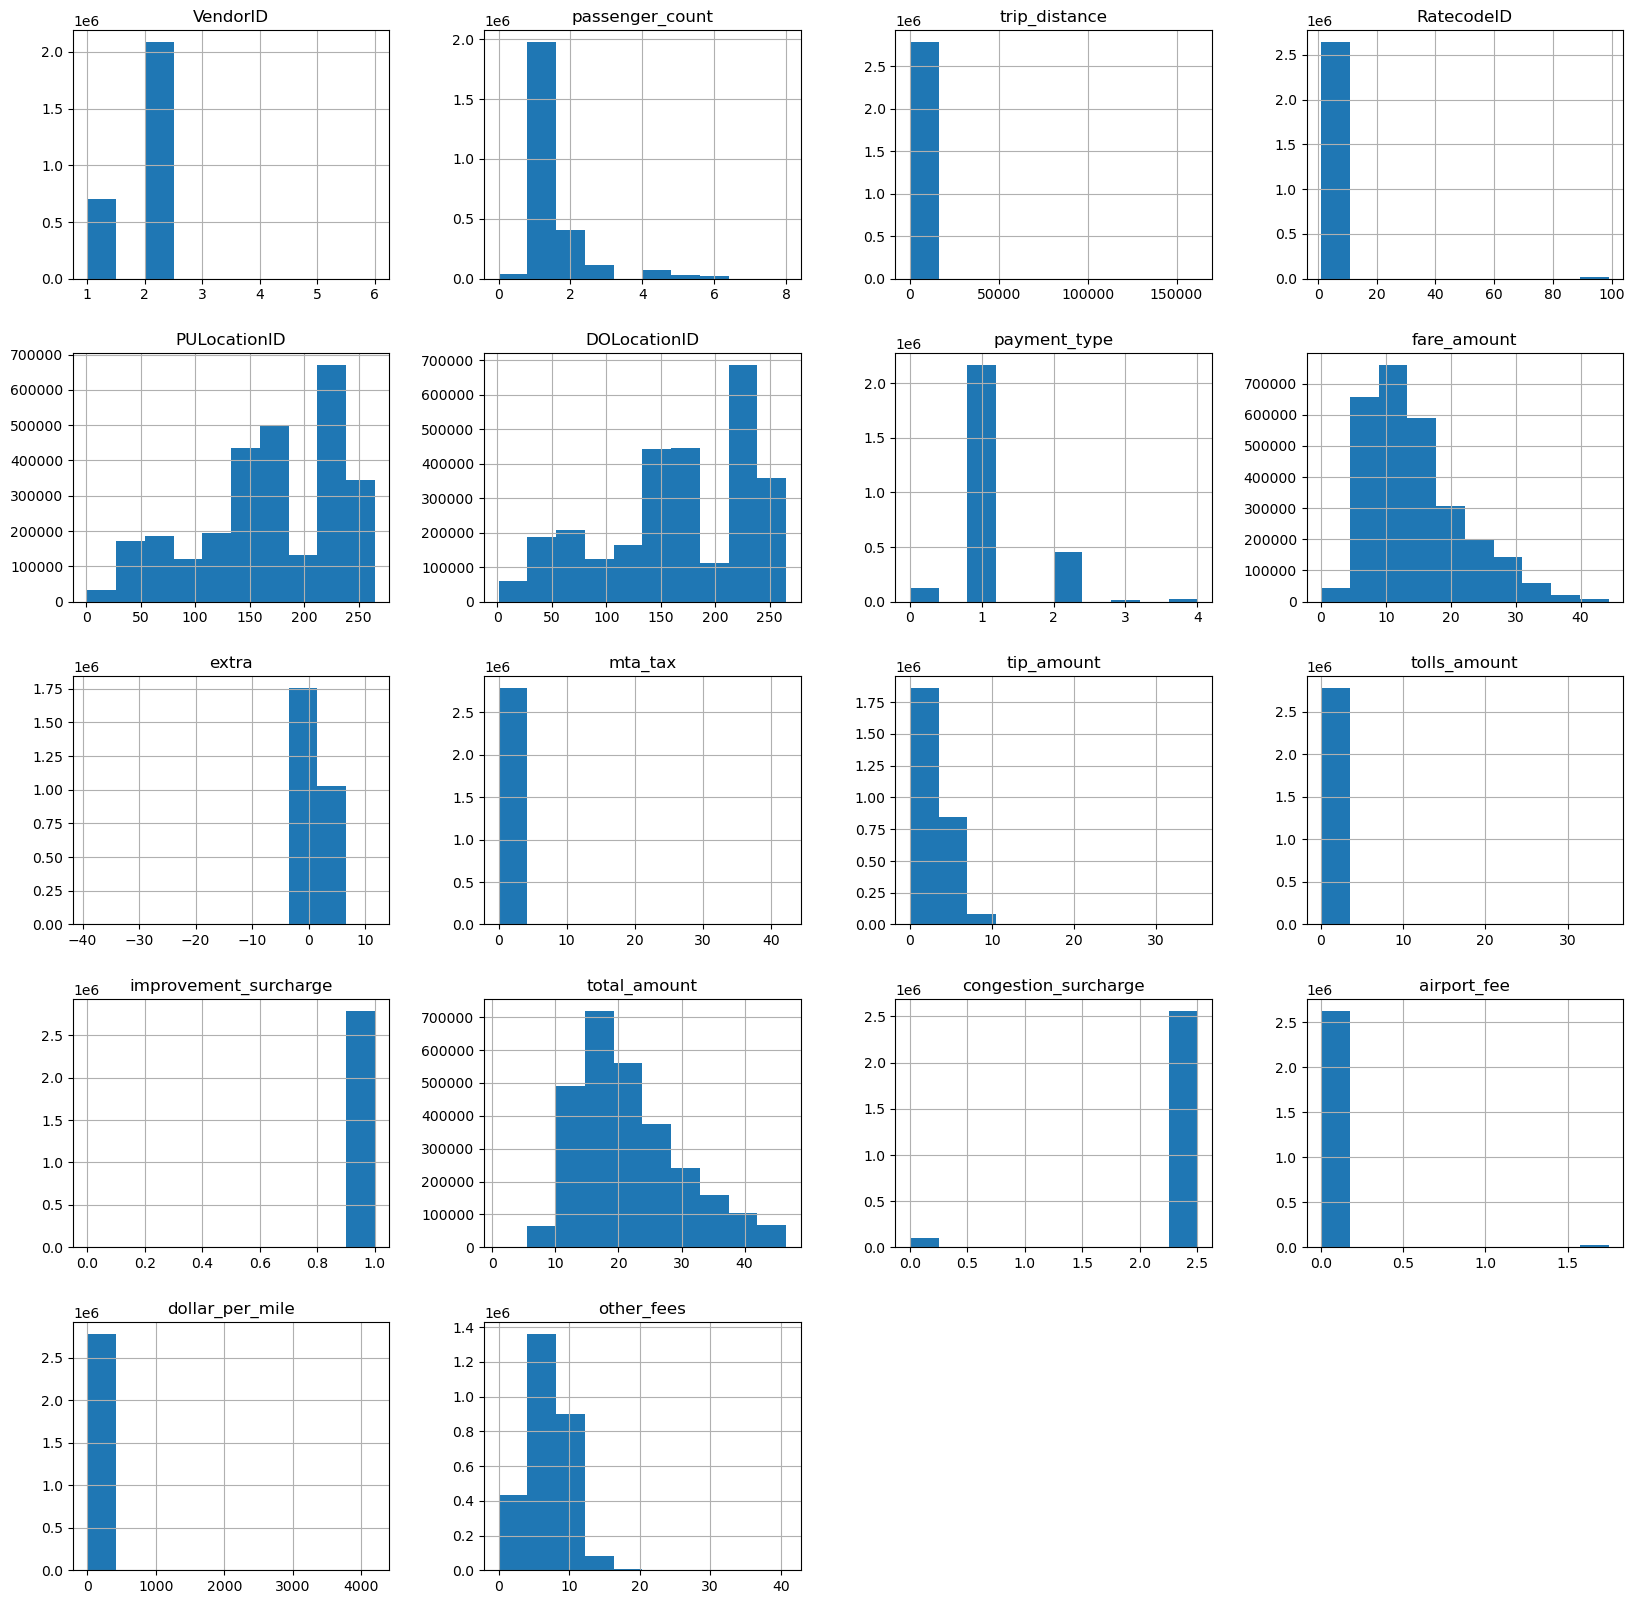

In [58]:
df.head()
df[['total_amount', 'fare_amount', 'other_fees']].corr()
df[['dollar_per_mile', 'total_amount']].describe()
df.hist(figsize=(20,20))



### Step 2: Propose three candidate **X** predictors (numeric)

Pick three different X columns that are **numeric** and **known at decision time**.

In [ ]:
y = df['dollar_per_mile']
X1 = sm.add_constant(df['fare_amount'])  # change of per mile base_fare Y as fare amount increase or decrease
X2 = sm.add_constant(df['total_amount']) # How per mile base fare relates to total cost
X3 = sm.add_constant(df['other_fees']) # how other fee than fare net correlate to fare rate: per_mile base fare

### Step 3: Fit three one‑variable models with the SAME Y and different Xs

In [74]:
model1 = sm.OLS(y,X1).fit()
model2 = sm.OLS(y,X2).fit()
model3 = sm.OLS(y,X3).fit()

#print(model1.summary())
#print(model2.summary())
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:        dollar_per_mile   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4372.
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:55:18   Log-Likelihood:            -1.3056e+07
No. Observations:             2785853   AIC:                         2.611e+07
Df Residuals:                 2785851   BIC:                         2.611e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.6454      0.048    262.288      0.0

### Step 4: Visual check for the “best” model candidate

Pick the model you currently prefer (based on business sense + evidence).
- Create a scatter of X vs. Y with the fitted line.

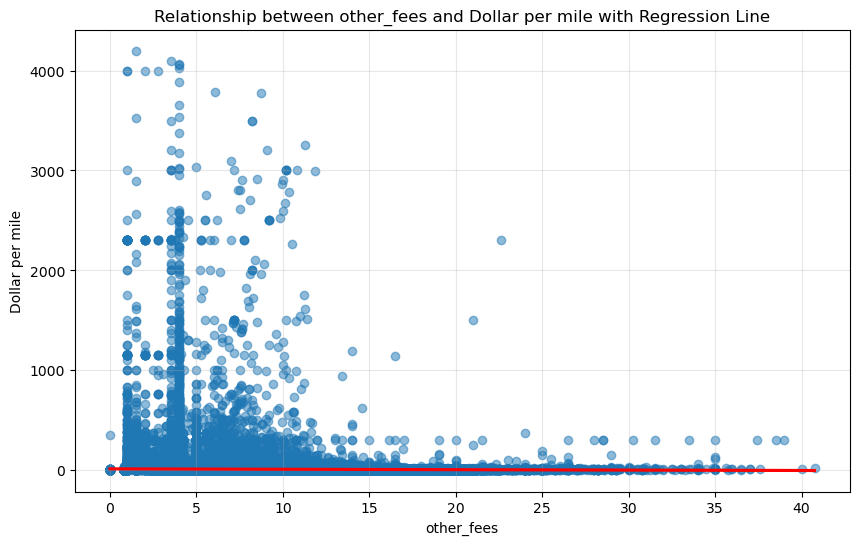

In [75]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='other_fees', y='dollar_per_mile', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('other_fees')
plt.ylabel('Dollar per mile')
plt.title('Relationship between other_fees and Dollar per mile with Regression Line')
plt.grid(True, alpha=0.3)
plt.show()

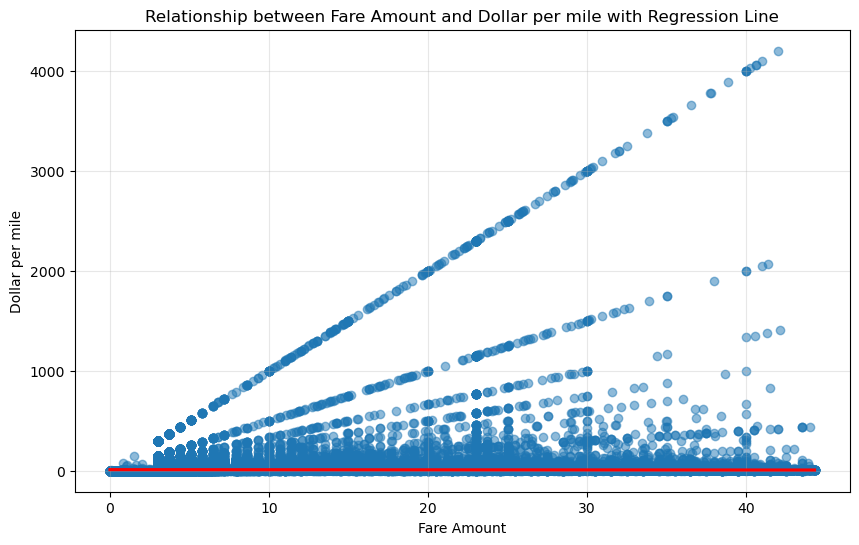

In [76]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='fare_amount', y='dollar_per_mile', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('Fare Amount')
plt.ylabel('Dollar per mile')
plt.title('Relationship between Fare Amount and Dollar per mile with Regression Line')
plt.grid(True, alpha=0.3)
plt.show()

### Step 5: Interpret Each Model (write in plain English)
Fill the three blocks below. Use **units** and **percentage points (pp)** where relevant.

- **Slope (β₁):** “For each +1 unit of X, Y changes by …”
- **Intercept (β₀):** meaningful or just a math anchor? Explain.
- **p‑value:** is there evidence the slope ≠ 0?
- **R²:** how much variation does this X explain?
- **Judgment:** is the effect size **practically** meaningful (tie to business)?

### Model A — Y = Dollar per mile ~ Fare amount = Fare amount
- Slope (β₁): For every additional dollar unit fare, the ration dollar per distance see a decrease for about 0.08 dollar unit. so higher-fare trips which are usually longer,tend to have slightly very very cheaper cost per mile 
- Intercept (β₀): the baseline dollar per mile is $10.82 unit, this is however a math anchor as it is unrealistic to record $0 for fare
- p‑value (slope): P_value is ~0, showing enough significance evidence
- 95% CI for slope: very wide confidence interval,[0.025 - 0.975], this shows uncertainty on how strong the effect really is.
- R²: the fare amount explains only 0.1 % of the variation, incredibly small. other factors like distance may explain it better 
- Business readout (units):As fare get higher, the dollar per mile tend to decrease for only $0.08, so longer trip tend to be cheaper but in a very very small scale. Also, the trend is statistically significant but practically small.
- One limitation: The model's R_square is only 0.01, very small to explain the variation seen in dollar per mile

### Model B — Y = Dollar per mile ~ total_amount = total amount
- Slope (β₁): -0.10: For each $1 increase in total amount, the dollar per mile decreases by $0.10
- Intercept (β₀): when total amount = $0, the fare per mile is estimated at $11.84 , but this is just a math anchor
- p‑value (slope): The relationship is statistically significant with p_value ~0
- 95% CI for slope: [−0.025, −0.975] The true slope likely lies between this interval,wide interval means uncertainty on how strong the relation is.
- R²: Only 0.1% of the variation in dollar per mile is explained by total amount, other factors contribute heavily
- Business readout (units): Even though total amount and Dollar per mile are connected since fare is part of total amount, the relationship shows that as trips get more expensive overall, their per-mile cost tends to drop slightly by $0.10. Longer rides being relatively cheaper per mile than short ones.
However, the effect is so small that total amount alone tells us almost nothing about per mile pricing.
- One limitation: with very small R square, almost no explanatory power

### Model C — Y =  Dollar per mile ~ other_fees = other_fees
- Slope (β₁): For every additional dollar in other fees, the ratio dollar per distance decreases by about $0.41. maybe because the other fixed charges like taxes, airport fees, extra get spread over more distance 
- Intercept (β₀): The baseline dollar per mile is $12.64, which is only a math anchor because it’s unrealistic to have a trip with $0 of other fees.
- p‑value (slope): the p-value ≈ 0, providing strong evidence that this relationship is statistically significant.
- 95% CI for slope: The confidence interval is [−0.421 , −0.397], showing a precise estimate and confirming a consistently negative relationship.
- R²: The other fees variable explains about 0.2 % of the variation in dollar per mile, also very small, meaning many other factors are influencing the outcome.
- Business readout (units): As other fees increase by $1, the fare per mile decreases by roughly $0.41. Basically longer or more complex trips that accumulate higher extra charges are slightly cheaper per mile, but this effect is still extremely small. The trend is statistically significant but not meaningful for business decisions by itself.
- One limitation: The model’s R² = 0.002 is too low to explain real variation in dollar per mile.

## We Share (10 mins) — Reflection & Decision (write 1-2 short paragraphs)

1) **Which model is “better” for a stakeholder decision and why?**
- Weigh **evidence** (p‑value, CI), **explanatory power** (R²), **interpretability**, and **business impact** (units, MDE if relevant).
2) **What would you do next week to strengthen trust in this model?**
- (Preview) time‑based validation, hold‑out testing, segment checks, adding more plausible X’s, checking assumptions.